In [84]:
import pandas as pd

df = pd.read_csv("healthcare_dataset.csv")




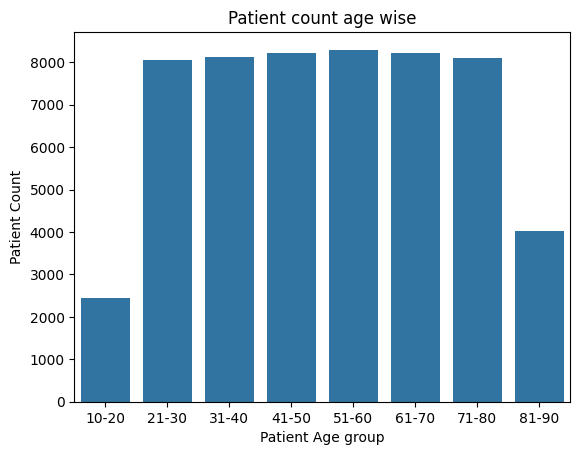

Patient count by:
 Age_Group
51-60    8297
61-70    8228
41-50    8209
31-40    8125
71-80    8107
21-30    8056
81-90    4035
10-20    2443
Name: count, dtype: int64
Max patient count: 8297 -> Age group: 51-60
Min patient count: 2443 -> Age group: 10-20


In [85]:
## Task 1 — Demographic Breakdown of Patients



import matplotlib.pyplot as plt
import seaborn as sns
 
df["Age_Group"]=pd.cut(df["Age"],bins=[10,20,30,40,50,60,70,80,90],
    labels=["10-20","21-30","31-40","41-50","51-60","61-70","71-80","81-90"])

sns.countplot(data=df, x="Age_Group", order=["10-20","21-30","31-40",
              "41-50","51-60","61-70","71-80","81-90"])
plt.title("Patient count age wise")
plt.xlabel("Patient Age group")
plt.ylabel("Patient Count")
plt.show()

age_counts = df["Age_Group"].value_counts()
print("Patient count by:\n", age_counts)

print("Max patient count:", age_counts.max(), 
      "-> Age group:", age_counts.idxmax())

print("Min patient count:", age_counts.min(), 
      "-> Age group:", age_counts.idxmin())




MALE AND FEMALE PATIENT PERCENTAGE : Gender
Male      50.043243
Female    49.956757
Name: proportion, dtype: float64


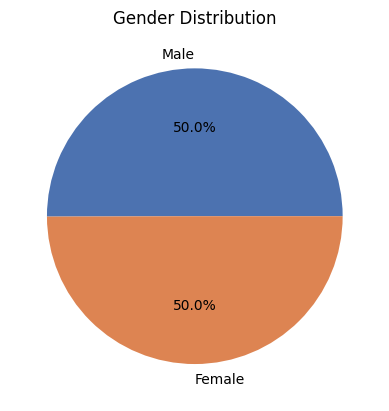

In [86]:
gend_er_data = df["Gender"].value_counts(normalize=True)*100
print("MALE AND FEMALE PATIENT PERCENTAGE :",gend_er_data)

plt.pie(gend_er_data,labels=gend_er_data.index,autopct='%1.1f%%',
        colors=["#4C72B0","#DD8452"])
plt.title("Gender Distribution")
plt.show()

In [87]:
Blood_group_data=df["Blood Type"].value_counts().sort_values()
print("The most common Bloodgroup:",Blood_group_data.values.max())
print("The least common Bloodgroup:",Blood_group_data.values.min())
print(Blood_group_data)


The most common Bloodgroup: 6969
The least common Bloodgroup: 6877
Blood Type
O-     6877
O+     6917
B-     6944
AB-    6945
B+     6945
AB+    6947
A+     6956
A-     6969
Name: count, dtype: int64


- Age distribution is spread evenly across all groups from 10 to 90.
- 10–20 bracket has the lowest patient count — younger individuals have lower hospital dependency.
- Gender split is approximately 50/50.
- A- is the most common blood type (6,969), O- is the least common (6,877).

In [88]:
## Task 2 — Medical Condition Analysis by Gender and Age Group

df["Medical Condition"].value_counts()


Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64

In [89]:
df.groupby("Age_Group")["Medical Condition"].value_counts().unstack(fill_value=0)

Medical Condition,Arthritis,Asthma,Cancer,Diabetes,Hypertension,Obesity
Age_Group,,,,,,
10-20,428,408,417,401,386,403
21-30,1302,1338,1359,1329,1339,1389
31-40,1403,1358,1336,1356,1350,1322
41-50,1380,1344,1333,1415,1355,1382
51-60,1401,1310,1394,1384,1388,1420
61-70,1332,1379,1345,1456,1351,1365
71-80,1374,1372,1364,1321,1396,1280
81-90,688,676,679,642,680,670


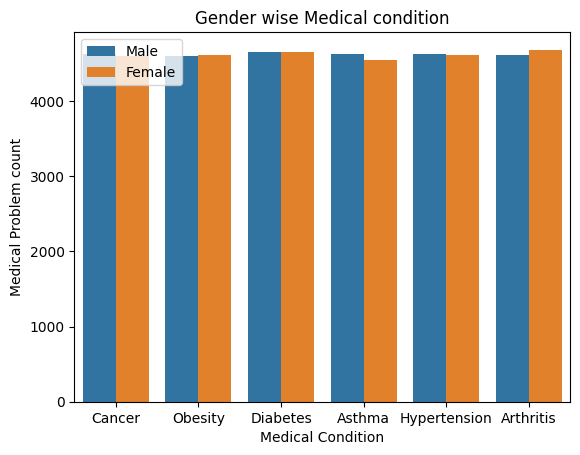

Patient sex wise data:
 Medical Condition  Arthritis  Asthma  Cancer  Diabetes  Hypertension  Obesity
Gender                                                                       
Female                  4686    4553    4602      4651          4612     4622
Male                    4622    4632    4625      4653          4633     4609


In [90]:
gender_data=df.groupby("Gender")["Medical Condition"].value_counts().unstack(fill_value=0)


sns.countplot(data=df,x="Medical Condition",hue="Gender")
plt.title("Gender wise Medical condition")
plt.ylabel("Medical Problem count")
plt.legend(loc="upper left")
plt.show()

print("Patient sex wise data:\n",gender_data)

- No medical condition shows a strong gender preference.
- Arthritis has the largest gender gap — Female (4,686) vs Male (4,622).
- Patient counts are stable across age groups 21-80.
- 10-20 group shows the lowest prevalence — consistent with fewer chronic illnesses in younger individuals.

In [91]:
## Task 3 — Length of Stay Analysis

df.head()

df["date_stay"]=pd.to_datetime(df["Date of Admission"],format="mixed",dayfirst=True)
df["date_discharge"]=pd.to_datetime(df["Discharge Date"],format="mixed",dayfirst=True)
df["stay_duration"]=(df["date_discharge"]-df["date_stay"]).dt.days
stay_df = df[df["stay_duration"] >= 0]
stay_df.sort_values("stay_duration", ascending=False)
print(stay_df[["date_stay", "date_discharge", "stay_duration"]].head())

   date_stay date_discharge  stay_duration
0 2024-01-31     2024-02-02              2
1 2019-08-20     2019-08-26              6
3 2020-11-18     2020-12-18             30
5 2023-12-20     2023-12-24              4
6 2020-03-11     2020-11-15            249


In [92]:
df.groupby("Medical Condition")["stay_duration"].mean()

Medical Condition
Arthritis       15.672432
Asthma          16.036037
Cancer          15.228352
Diabetes        15.388650
Hypertension    17.114981
Obesity         15.572094
Name: stay_duration, dtype: float64

In [93]:
df.groupby(["Medical Condition","Admission Type"])["stay_duration"].mean().unstack()

Admission Type,Elective,Emergency,Urgent
Medical Condition,,,
Arthritis,15.851443,15.534749,15.632660
Asthma,15.906190,17.005996,15.221681
Cancer,14.267154,19.669983,11.845300
Diabetes,14.128188,17.032151,15.046764
Hypertension,18.625272,15.520493,17.088654
Obesity,18.622412,14.101088,14.042456


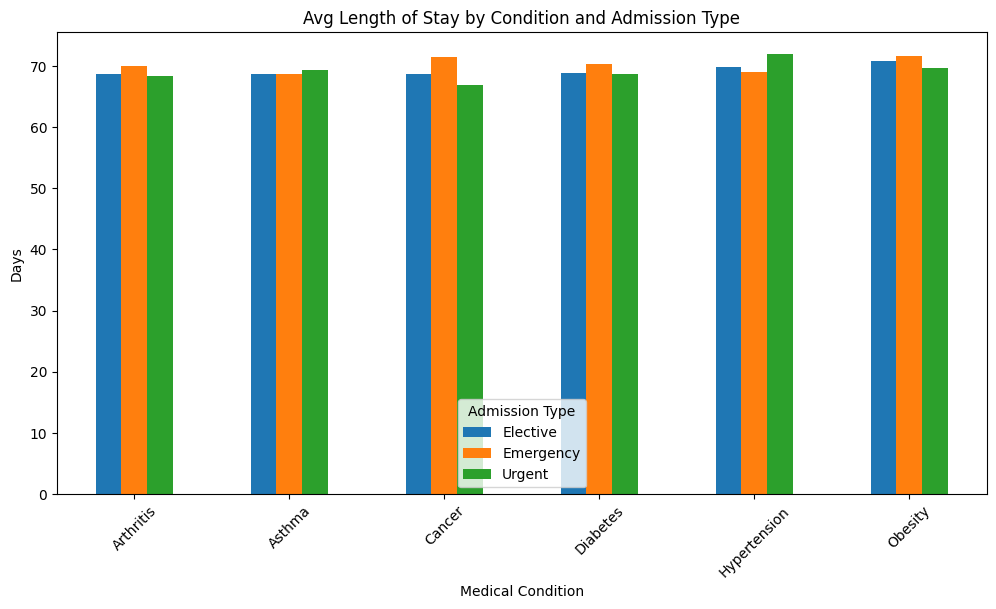

In [94]:
stay_df.groupby(["Medical Condition","Admission Type"])["stay_duration"].mean().unstack().plot(kind="bar", figsize=(12,6))
plt.title("Avg Length of Stay by Condition and Admission Type")
plt.ylabel("Days")
plt.xticks(rotation=45)
plt.legend(title="Admission Type")
plt.show()

- Cancer Emergency cases have the longest average stay at 19.67 days.
- Cancer Urgent cases are the shortest at 11.85 days — a 7-day difference driven purely by admission type.
- Hypertension and Obesity Elective cases average ~18.6 days each.
- Admission type has more influence on stay duration than medical condition alone.

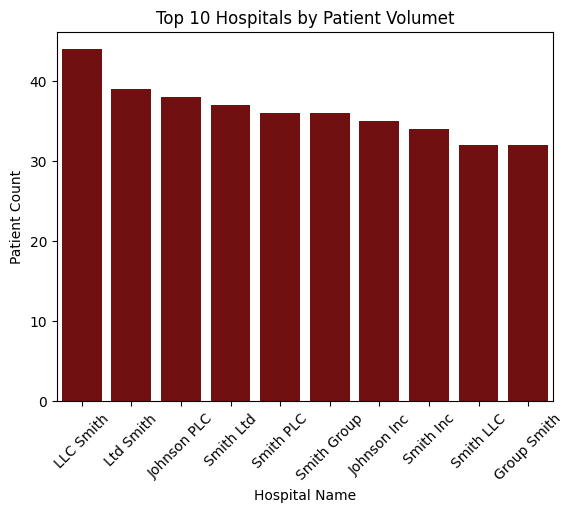

Hospital
LLC Smith      44
Ltd Smith      39
Johnson PLC    38
Smith Ltd      37
Smith PLC      36
Smith Group    36
Johnson Inc    35
Smith Inc      34
Smith LLC      32
Group Smith    32
Name: count, dtype: int64


In [95]:
## Task 4 — Hospital and Doctor Volume Analysis

Hospital_count=df["Hospital"].value_counts().head(10)

plt.xticks(rotation=45)
sns.barplot(data=Hospital_count,color="maroon")
plt.title("Top 10 Hospitals by Patient Volumet")
plt.xlabel("Hospital Name")
plt.ylabel("Patient Count")
plt.show()

print(Hospital_count)

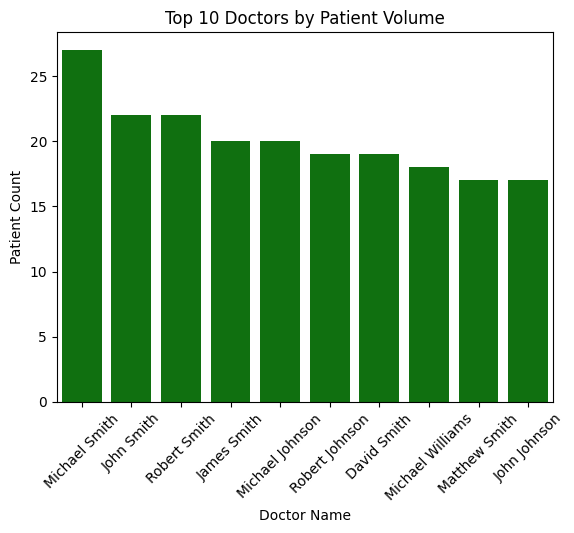

Doctor
Michael Smith       27
John Smith          22
Robert Smith        22
James Smith         20
Michael Johnson     20
Robert Johnson      19
David Smith         19
Michael Williams    18
Matthew Smith       17
John Johnson        17
Name: count, dtype: int64


In [96]:
Doctor_count=df["Doctor"].value_counts().head(10)

plt.xticks(rotation=45)
sns.barplot(data=Doctor_count,color="Green")
plt.xlabel("Doctor Name")
plt.ylabel("Patient Count")
plt.title("Top 10 Doctors by Patient Volume")
plt.show()

print(Doctor_count)

- Top hospital handles 44 patients, several handle just 1.
- Michael Smith leads doctor volume with 27 patients.
- No single hospital or doctor dominates — indicates a decentralized healthcare network.

In [97]:
## Task 5 — Billing Amount Analysis

df.groupby("Medical Condition")["Billing Amount"].mean()

Medical Condition
Arthritis       25497.327056
Asthma          25635.249359
Cancer          25161.792707
Diabetes        25638.405577
Hypertension    25497.095761
Obesity         25805.971259
Name: Billing Amount, dtype: float64

In [98]:
df.groupby("Insurance Provider")["Billing Amount"].mean()

Insurance Provider
Aetna               25553.294506
Blue Cross          25613.011503
Cigna               25525.766314
Medicare            25615.990508
UnitedHealthcare    25389.172390
Name: Billing Amount, dtype: float64

In [99]:
df.groupby("Admission Type")["Billing Amount"].mean()

Admission Type
Elective     25602.226311
Emergency    25497.397157
Urgent       25517.364497
Name: Billing Amount, dtype: float64

In [100]:
df[["Name","Medical Condition","Admission Type","Billing Amount"]].sort_values(by="Billing Amount",ascending=False).head(10)


,Name,Medical Condition,Admission Type,Billing Amount
36349,tOdd CARrILlO,Hypertension,Elective,52764.276736
51313,kARen klInE,Cancer,Urgent,52373.032374
34613,kARen klInE,Cancer,Urgent,52373.032374
5735,DAVId SanDOvaL,Hypertension,Emergency,52271.663747
7088,kathRYN GoNzales,Diabetes,Urgent,52211.852966
1574,BRETT mARshAll,Asthma,Emergency,52181.837792
52826,LAuRie hOod,Arthritis,Urgent,52170.036854
6663,LAuRie hOod,Arthritis,Urgent,52170.036854
33117,JUstIn CLark,Cancer,Urgent,52154.237722
34368,sCotT pOWElL,Cancer,Emergency,52102.240889


In [101]:
df.groupby(["Insurance Provider","Admission Type"])["Billing Amount"].mean().unstack()

Admission Type,Elective,Emergency,Urgent
Insurance Provider,,,
Aetna,25431.610033,25352.767022,25895.929987
Blue Cross,25628.968960,25568.703588,25640.435026
Cigna,26013.703380,25234.381667,25334.635787
Medicare,25640.454624,25596.092870,25611.548491
UnitedHealthcare,25303.096835,25740.172114,25137.169865


- Average billing is consistent across all medical conditions and insurance providers.
- Top 10 most expensive cases all exceed 52,000.
- Hypertension Elective tops at 52,764.
- Duplicate patient entries with identical billing amounts detected — data quality issue.
- Negative billing values found and flagged as anomalies.


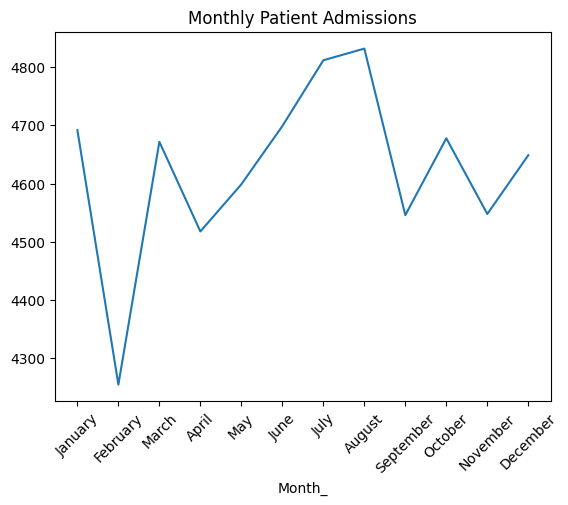

In [102]:
## Task 6 — Seasonal Admission Trends

df["Date of Admission"]=pd.to_datetime(df["Date of Admission"])
df["Month_"]=df["Date of Admission"].dt.month_name()

month_order = ["January","February","March","April","May","June",
  "July","August","September","October","November","December"]

patient_intake_monthly = df["Month_"].value_counts().reindex(month_order)

sns.lineplot(x=patient_intake_monthly.index, y=patient_intake_monthly.values)
plt.xticks(rotation=45)
plt.title("Monthly Patient Admissions")
plt.show()

- August records the highest admissions (4,832), followed by July and June.
- Summer months consistently show slightly elevated patient intake.
- February has the lowest admissions (4,255) — shortest month effect.
- No extreme seasonal spikes observed overall.

In [103]:
## Task 7 — Doctor Ranking by Billing Amount (SQL Window Function)

import pandas as pd
import sqlite3

df = pd.read_csv("healthcare_dataset.csv")

conn = sqlite3.connect("healthcare.db")
df.to_sql("patients", conn, if_exists="replace", index=False)

query = """
SELECT 
    Doctor,
    Hospital,
    ROUND(AVG("Billing Amount"), 2) AS avg_billing,
    RANK() OVER (PARTITION BY Hospital ORDER BY AVG("Billing Amount") DESC) AS doctor_rank
FROM patients
GROUP BY Hospital, Doctor
ORDER BY Hospital, doctor_rank
"""

result = pd.read_sql_query(query, conn)
print(result.head(20))

              Doctor                       Hospital  avg_billing  doctor_rank
0       Brandi Lucas                     Abbott Inc     38052.04            1
1     Jessica Arnold                     Abbott Ltd     29877.59            1
2       Jordan Black     Abbott Moore and Williams,     24799.60            1
3   Angela Hernandez  Abbott and Thompson, Sullivan     16738.57            1
4       Kelsey Logan     Abbott, Peters and Hoffman     18842.40            1
5     Jason Williams   Abbott, Vazquez Bautista and     14117.14            1
6      Brian Roberts                Abbott-Castillo     18397.74            1
7         Jake Patel                 Abbott-Coleman     19752.00            1
8         Amy Murray                 Abbott-Ferrell        99.93            1
9        Erin Garcia                    Abbott-Hill     13260.14            1
10     David Spencer                   Abbott-Jones     49039.71            1
11   George Gonzalez                  Abbott-Martin     48968.88

In [104]:
## Task 8 — Patient Billing Percentile by Medical Condition (SQL Window Function)


code="""
SELECT "Name","Medical Condition","Billing Amount",
ROUND(PERCENT_RANK()OVER(PARTITION BY "Medical Condition" ORDER BY "Billing Amount"),2) AS Billing_percentile
FROM patients 
"""

result = pd.read_sql_query(code, conn)
result = result[result["Billing Amount"] >= 0]
print("Top 5 Highest Billing Patients:\n", result.sort_values("Billing_percentile", ascending=False).head())
print("\nTop 5 Lowest Billing Patients:\n", result.sort_values("Billing_percentile", ascending=True).head())

Top 5 Highest Billing Patients:
                Name Medical Condition  Billing Amount  Billing_percentile
55499     TOm smItH           Obesity    52024.726443                 1.0
9285   michaEl lANE         Arthritis    50902.019047                 1.0
9295       aNnE LeE         Arthritis    51293.412042                 1.0
9294    COrey fLOYd         Arthritis    51257.620793                 1.0
9293   CiNdY ortEga         Arthritis    51181.564927                 1.0

Top 5 Lowest Billing Patients:
                    Name Medical Condition  Billing Amount  Billing_percentile
11           LACEy roSs         Arthritis       32.626843                 0.0
18521    ROBeRta mILLER            Cancer      323.820083                 0.0
18522  BENjAMIN brenNan            Cancer      341.958408                 0.0
18523     GeoRGE mIller            Cancer      363.666200                 0.0
18524      AmBEr hoDgES            Cancer      386.860478                 0.0


- Each patient assigned a billing percentile within their medical condition group using PERCENT_RANK().
- A patient at 0.95 means they are in the top 5% most expensive cases within their condition.
- Useful for identifying outlier cases for billing review or insurance flagging.
- Negative billing entries filtered out prior to analysis.

In [105]:
## Task 9 — Factors Affecting Length of Stay

rec=stay_df[["Age","stay_duration"]].corr()
print(rec)





                    Age  stay_duration
Age            1.000000       0.003837
stay_duration  0.003837       1.000000


In [106]:
stay_df.groupby(["Medical Condition","Admission Type"])["stay_duration"].mean()

Medical Condition  Admission Type
Arthritis          Elective          68.610077
                   Emergency         70.029878
                   Urgent            68.291704
Asthma             Elective          68.629061
                   Emergency         68.754296
                   Urgent            69.257812
Cancer             Elective          68.629032
                   Emergency         71.416744
                   Urgent            66.931131
Diabetes           Elective          68.873200
                   Emergency         70.278918
                   Urgent            68.706063
Hypertension       Elective          69.866553
                   Emergency         69.060563
                   Urgent            71.909644
Obesity            Elective          70.841291
                   Emergency         71.702925
                   Urgent            69.694597
Name: stay_duration, dtype: float64

- Age shows virtually no correlation with stay duration (r = 0.0038).
- Cancer Emergency drives the longest stays — consistent with Task 3 findings.
- Admission type appears to have more influence on stay duration than medical condition.


In [107]:
## Task 10 — Patient Risk Segmentation (CASE WHEN / np.select)


query = """
SELECT 
    risk_segment,
    "Medical Condition",
    COUNT(*) AS patient_count
FROM (
    SELECT 
        "Medical Condition",
        "Billing Amount",
        CASE 
            WHEN "Billing Amount" < 10000 THEN 'Low'
            WHEN "Billing Amount" BETWEEN 10000 AND 30000 THEN 'Medium'
            ELSE 'High'
        END AS risk_segment
    FROM patients
) AS sub
GROUP BY risk_segment, "Medical Condition"
ORDER BY risk_segment, patient_count DESC
"""

result = pd.read_sql_query(query, conn)
print(result)

   risk_segment Medical Condition  patient_count
0          High           Obesity           3876
1          High          Diabetes           3847
2          High         Arthritis           3806
3          High      Hypertension           3760
4          High            Asthma           3729
5          High            Cancer           3652
6           Low            Cancer           1776
7           Low         Arthritis           1756
8           Low      Hypertension           1718
9           Low          Diabetes           1694
10          Low            Asthma           1665
11          Low           Obesity           1643
12       Medium            Cancer           3799
13       Medium            Asthma           3791
14       Medium      Hypertension           3767
15       Medium          Diabetes           3763
16       Medium         Arthritis           3746
17       Medium           Obesity           3712


In [108]:
# TASK 10  WITH NUMPY AND PANDAS
import numpy as np
condition=[df["Billing Amount"]<10000,
 (df["Billing Amount"] > 10000) & (df["Billing Amount"] < 30000)  ,df["Billing Amount"]>30000]
choices=["LOW","MEDIUM","HIGH"]
df["patient_segment"]=np.select(condition,choices,default="LOW")
df.groupby("patient_segment")["Medical Condition"].value_counts()

pivot = pd.pivot_table(
    df,
    index="patient_segment",
    columns="Medical Condition",
    aggfunc="size",
    fill_value=0
)

print(pivot)

Medical Condition  Arthritis  Asthma  Cancer  Diabetes  Hypertension  Obesity
patient_segment                                                              
HIGH                    3806    3729    3652      3847          3760     3876
LOW                     1756    1665    1776      1694          1718     1643
MEDIUM                  3746    3791    3799      3763          3767     3712


- Patients segmented into Low < 10,000, Medium 10,000-30,000, High > 30,000 billing.
- High segment is the largest — most patients fall in the premium billing range.
- All six medical conditions appear across all three segments with no single condition dominating.
- Framework can be adapted for insurance risk modeling or hospital resource allocation.